# Lecture 8 - Introduction to Clustering

## Today's Class

By the end of this class, you will be able to

- Explain what **clustering** is and how it differs from supervised learning methods (no outcome variable).
- Describe common **distance metrics** (Euclidean, Manhattan, cosine) and explain why the choice of metric matters.
- Explain why **standardization** is essential before applying distance-based clustering algorithms.
- Explain the **K-Means** algorithm (initialization, assignment, update steps) and its key assumptions.
- Fit a K-Means model using `KMeans` and choose the number of clusters using the **elbow method** and **silhouette score**.
- Understand how **hierarchical (agglomerative) clustering** works, interpret a **dendrogram**, and compare linkage methods (single, complete, average, Ward).
- Apply `AgglomerativeClustering` from scikit-learn and visualize the resulting clusters.
- Compute and interpret **clustering evaluation metrics**: inertia, silhouette score, Davies-Bouldin index, and Calinski-Harabasz index.
- Compare clustering algorithms on the same dataset and discuss practical trade-offs.

## Packages for clustering

- New packages for this week are in `sklearn`:

- `sklearn.preprocessing` for `StandardScaler` for standardizing variables
- `scipy.spatial.distance` for distance metrics
- `sklearn.cluster` for `KMeans` and `AgglomerativeClustering` for clustering
- `scipy.cluster.hierarchy` for cluster hierarchy (tree/dendrogram)
- `sklearn.metrics` for cluster evaluation metrics
   

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import euclidean

### Clustering Methods and Goals

Clustering algorithms belong to the family of **unsupervised learning** methods. Unlike regression or classification, there is no outcome variable $y$ to predict — the algorithm receives only a matrix of features $X$ and must discover structure on its own.

The core idea is simple: **observations that are similar to each other should belong to the same group**, and observations in different groups should be dissimilar. What counts as 'similar' is defined by a **distance metric** (more on this shortly).

**Three broad families of clustering algorithms:**

| Family | Key idea | Examples |
|---|---|---|
| **Partitioning** | Divide data into $k$ non-overlapping groups by optimizing a criterion. Sometimes called centroid-based  | K-Means, K-Medoids |
| **Hierarchical** | Build a tree of nested clusters by successively merging or splitting groups | Agglomerative, Divisive |
| **Density-based** | Define clusters as dense regions separated by sparse regions | DBSCAN, HDBSCAN |

![Cluster Types](clustertypes.webp)
*Source:https://medium.com/@kiranvutukuri/28-clustering-algorithms-k-means-dbscan-and-hierarchical-4fbac2ad0bc0*


**Real-world examples of clustering in practice:**

- **Retail / marketing** — a supermarket groups customers by purchasing behavior (frequency, basket size, product categories) to target promotions. No one told the algorithm what a 'loyal bulk-buyer' or 'occasional treat-shopper' looks like — it finds those patterns itself.
- **Genomics** — researchers cluster thousands of genes by their expression profiles across experimental conditions to identify genes that are co-regulated, without knowing in advance which biological pathways exist.
- **News / social media** — articles or posts are grouped by topic so that similar stories are surfaced together, even though no one has manually labelled each article with a topic.
- **Public health** — patients are grouped by symptom profiles or lab results to identify disease subtypes that may respond differently to treatment.
- **Our application** — we group recipes by their nutritional profiles. We do not tell the algorithm anything about cuisine nationality; after clustering we ask: do the groups correspond to recognizable culinary traditions?

> **Key limitation:** because there is no ground truth, evaluating clustering is hard. Two algorithms applied to the same data can produce very different — and both defensible — groupings. Interpretation and domain knowledge always matter.

- We are going to focus on k-means and hierarchical clustering today

Let's look at some simulated data to better understand clustering methods. We simulate two variables (Feature 1 and Feature 2) and plot Feature 1 vs Feature 2.

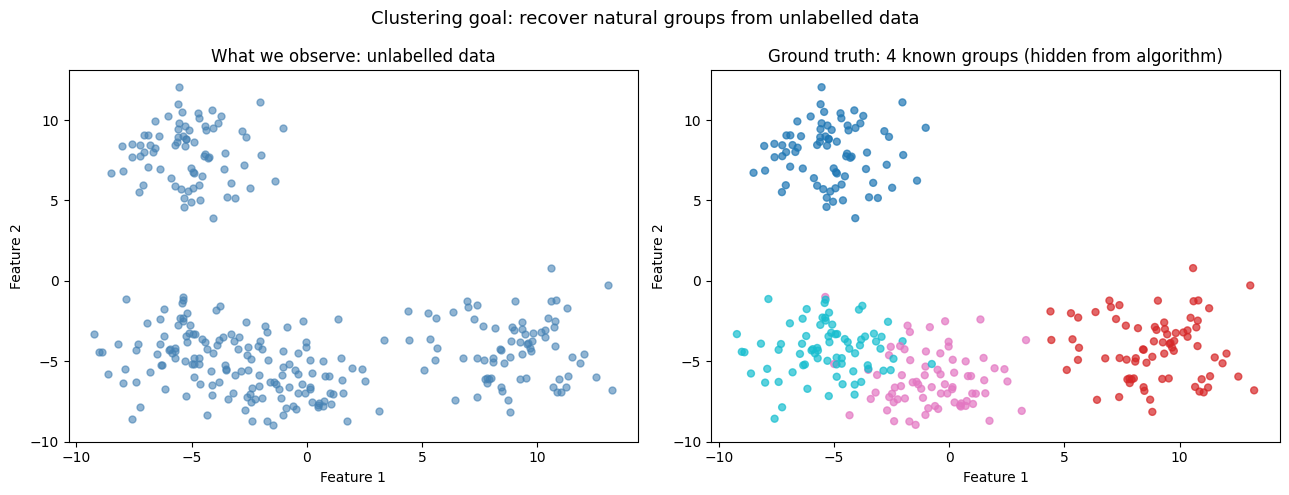

In [ ]:
from sklearn.datasets import make_blobs

X_sim, y_sim = make_blobs(n_samples=300, centers=4, cluster_std=1.8, random_state=272)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: what the algorithm sees — no labels
axes[0].scatter(X_sim[:, 0], X_sim[:, 1], color='steelblue', alpha=0.6, s=25)
axes[0].set_title('What we observe: unlabelled data')
axes[0].set_xlabel('Feature 1'); axes[0].set_ylabel('Feature 2')

# Right: ground truth we are trying to recover
axes[1].scatter(X_sim[:, 0], X_sim[:, 1], c=y_sim, cmap='tab10', alpha=0.7, s=25)
axes[1].set_title('Ground truth: 4 known groups (hidden from algorithm)')
axes[1].set_xlabel('Feature 1'); axes[1].set_ylabel('Feature 2')

plt.suptitle('Clustering goal: recover natural groups from unlabelled data', fontsize=13)
plt.tight_layout()
plt.show()

## Distance Metrics 

Most clustering algorithms rely on a notion of **distance** between observations. The most common metric for continuous/mixed data is:

**Euclidean distance**, also called straight-line distance:
$$d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{j=1}^{p} (a_j - b_j)^2}$$

- In k-means, similarity is tied to squared Euclidean distance to cluster centroids
- K-Means and most scikit-learn methods use **Euclidean distance** by default 
- Hierarchical clustering and density based clustering can use other distances

Distance metrics usually define dissimilarity, and therefore imply a notion of similarity, but the clustering algorithm may add extra structure to what “similar” means.

$$\text{similarity} \uparrow \quad \quad \text{distance} \downarrow$$

## K-Means Clustering

K-means is an iterative algorithm that partitions n observations into exactly k clusters. The goal is to minimize the within-cluster sum of squares: the total squared distance between each observation and the center of its assigned cluster:
$$
\sum_{j=1}^{k} \sum_{\mathbf{x}_i \in C_j}
\left\|
\mathbf{x}_i -
\frac{1}{|C_j|}
\sum_{\mathbf{x}_\ell \in C_j} \mathbf{x}_\ell
\right\|^2
$$

In words: for every point $\mathbf{x}_i$, compare how far it is from its cluster center, which is the mean of the points in the same cluster $j$; square that distance; then add up these squared distances over all points.

The within cluster sum of squares is also called the **intertia**. Inertia is the total squared distance from each point to the centroid of the cluster it was assigned to.

**The algorithm proceeds in four steps:**

1. **Initialize** — place $k$ centroids in the feature space. Random placement works but `k-means++` (in the Python algorithm) spreads them out intelligently, giving a better starting point.

2. **Assign** — assign every observation to the nearest centroid. Each observation belongs to whichever cluster center it is closest to (by Euclidean distance). This partitions the data into $k$ groups.

3. **Update** — recompute each centroid as the **mean** of all observations currently assigned to it. The centroids shift to the centre of mass of their group.

4. **Repeat** — go back to step 2. Keep iterating until assignments no longer change (convergence) or a maximum number of iterations is reached.

Because the algorithm depends on the initial centroid positions, it can converge to different solutions on different runs. Running it multiple times (`n_init=10`) and keeping the best result guards against this.

> **Key limitation:** K-Means assumes clusters are roughly **spherical and similarly sized**. It will always produce exactly $k$ clusters even if the true structure is very different — and choosing $k$ is itself a challenge we will address with the elbow method and silhouette score.

### Can K-Means recover the true groups?

On this clean simulated data, K-Means should almost perfectly recover the true clusters.

The code below runs K-Means on the simulated data and compares what it finds to the true groups. Here is what each part does:

**Fitting the model**
```python
km_sim = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=272)
labels_sim = km_sim.fit_predict(X_sim)
```
- `n_clusters=4` tells K-Means how many groups to find — we set this to 4 because we know the truth here. In practice this is a choice we have to make.
- `init='k-means++'` uses a smarter starting point for the centroids rather than placing them randomly, which reduces the chance of a bad solution. [See](https://en.wikipedia.org/wiki/K-means%2B%2B) for more on `k-means++`.
- `n_init=10` runs the full algorithm 10 times from different starting points and keeps the best result, this guards against getting stuck in a local optimum.
- `fit_predict()` fits the model and immediately returns a cluster label (0, 1, 2, or 3) for every observation.

**The label alignment problem**
```python
label_map = {}
for k in range(4):
    mask = labels_sim == k
    label_map[k] = mode(y_sim[mask]).mode[0]
labels_aligned = np.array([label_map[l] for l in labels_sim])
accuracy = (labels_aligned == y_sim).mean()
```
K-Means has no concept of 'Group 0' vs 'Group 1' — it just assigns arbitrary integer labels. The cluster it calls **0** might correspond to the true group **2**. Before we can compute an agreement rate, we need to match each K-Means label to the true label it most often coincides with. This is called **label alignment** (or the assignment problem). We do it simply: for each K-Means cluster, we find the true label that appears most frequently among its members (`mode`), and use that as the mapping.

> **Note:** this alignment trick only works here because we have the true labels for validation. In real unsupervised clustering we never have true labels to check against — that is the whole point.

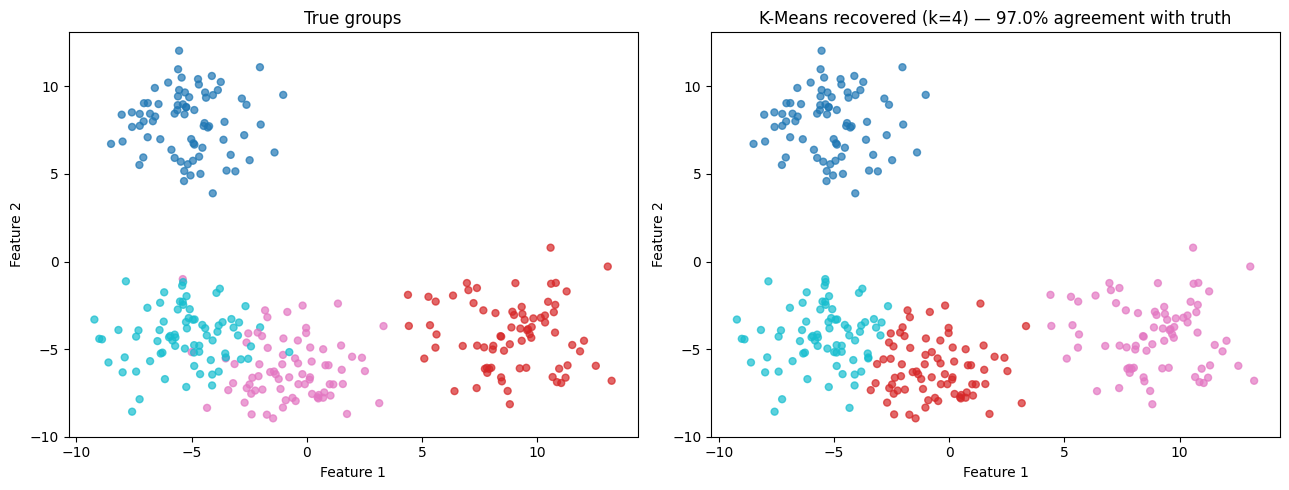

K-Means agreement with true labels: 97.0%
(Label permutations are arbitrary — clustering does not know the true names)


In [105]:
km_sim = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=272)
labels_sim = km_sim.fit_predict(X_sim)

from scipy.stats import mode
label_map = {}
for k in range(4):
    mask = labels_sim == k
    label_map[k] = mode(y_sim[mask], keepdims=True).mode[0]
labels_aligned = np.array([label_map[l] for l in labels_sim])
accuracy = (labels_aligned == y_sim).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_sim[:, 0], X_sim[:, 1], c=y_sim, cmap='tab10', alpha=0.7, s=25)
axes[0].set_title('True groups')
axes[1].scatter(X_sim[:, 0], X_sim[:, 1], c=labels_sim, cmap='tab10', alpha=0.7, s=25)
axes[1].set_title(f'K-Means recovered (k=4) — {accuracy:.1%} agreement with truth')
for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

print(f'K-Means agreement with true labels: {accuracy:.1%}')
print('(Label permutations are arbitrary — clustering does not know the true names)')

## Real Data: Cuisines Dataset

Let's try k-means on a pre-cleaned cuisines dataset (`cuisines_clean.csv`). These data are scraped from allrecipies.com. The clusters will be less obvious, nutritional profiles overlap across cuisines, but the goal and methods are identical.

Each row is a recipe tagged with a **country/cuisine label** — withheld during clustering and used only for post-hoc profiling.

| Feature used for clustering | Description |
|---|---|
| `calories` | Calories per serving |
| `pct_fat` | % of calories from fat |
| `pct_carbs` | % of calories from carbohydrates |
| `pct_protein` | % of calories from protein |
| `total_time` | Total prep + cook time (minutes, capped at 300) |

<br>

| Post-hoc cluster analysis  | Description |
|---|---|
| `country` | Cuisines, country of the food type in the recipe |


In [106]:
cuisines_clean = pd.read_csv('cuisines_clean.csv')

print(f'Shape: {cuisines_clean.shape}')
print(f'Cuisines (countries): {cuisines_clean["country"].nunique()}')
print()
print('Columns:', list(cuisines_clean.columns))
print()
cuisines_clean.head(10)

Shape: (1688, 14)
Cuisines (countries): 49

Columns: ['name', 'country', 'calories', 'fat', 'carbs', 'protein', 'avg_rating', 'prep_time', 'cook_time', 'total_time', 'servings', 'pct_fat', 'pct_carbs', 'pct_protein']



,name,country,calories,fat,carbs,protein,avg_rating,prep_time,cook_time,total_time,servings,pct_fat,pct_carbs,pct_protein
0,Saganaki (Flaming Greek Cheese),Greek,391.0,25.0,15.0,16.0,4.8,10,5,15,2.0,0.575448,0.153453,0.163683
1,Coney Island Knishes,Jewish,301.0,17.0,31.0,7.0,4.6,30,75,180,16.0,0.508306,0.411960,0.093023
2,Diana's Hawaiian Bread Rolls,Australian and New Zealander,64.0,3.0,9.0,1.0,4.3,20,15,180,12.0,0.421875,0.562500,0.062500
3,Chilean Pebre,Chilean,106.0,9.0,7.0,1.0,5.0,10,0,10,6.0,0.764151,0.264151,0.037736
4,Tex-Mex Sheet Cake,Tex-Mex,449.0,23.0,58.0,7.0,3.8,30,15,45,15.0,0.461024,0.516704,0.062361
5,Lemon Poppy Seed Amish Friendship Bread,Amish and Mennonite,157.0,6.0,25.0,2.0,4.6,0,0,0,24.0,0.343949,0.636943,0.050955
6,Pan con Tomate (Spanish Tomato Bread),Spanish,322.0,16.0,39.0,7.0,5.0,5,5,10,1.0,0.447205,0.484472,0.086957
7,"Lomo de Res, Cuban-Style Rib-Eye Steaks",Cuban,389.0,21.0,16.0,28.0,4.4,10,10,50,4.0,0.485861,0.164524,0.287918
8,Peruvian Chicha Morada Drink,Peruvian,253.0,2.0,63.0,6.0,4.7,10,50,300,10.0,0.071146,0.996047,0.094862
9,Moo Shu Pork,Chinese,355.0,8.0,53.0,17.0,4.6,15,15,60,8.0,0.202817,0.597183,0.191549


## Standardization for Clustering

Most clustering algorithms are **distance-based**: they group observations that are close together in feature space. This means the **scale** of variables matters enormously.

In our cuisines data:
- `calories` ranges from a few dozen to over 1,000 per serving
- `pct_fat`, `pct_carbs`, `pct_protein` are proportions — but their variances still differ
- `total_time` is in minutes — can range from a few minutes to several hours

Without scaling, `calories` or `total_time` would dominate the distance calculation simply because of their large numeric range. **StandardScaler** centers each variable to mean 0 and scales to standard deviation 1:

$$z = \frac{x - \bar{x}}{s_x}$$

> **Note:** here we are clustering on the full dataset with no train/test split, so we fit the scaler on all observations. If you were instead clustering on a training set and later assigning new observations to the discovered clusters, you would fit the scaler on the training data only and apply that same transformation to the new data — never refit it on the new observations.

In [107]:
cuisine_features = ['calories', 'pct_fat', 'pct_carbs', 'pct_protein','total_time']

X = cuisines_clean[cuisine_features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=cuisine_features)

print(f"Clustering on {X_scaled.shape[0]:,} observations, {X_scaled.shape[1]} features")
print()
print("Before scaling:")
print(cuisines_clean[cuisine_features].describe().round(2))
print()
print("After scaling (mean ≈ 0, std ≈ 1):")
print(X_scaled_df.describe().round(2))

Clustering on 1,688 observations, 5 features

Before scaling:
       calories  pct_fat  pct_carbs  pct_protein  total_time
count   1688.00  1688.00    1688.00      1688.00     1688.00
mean     345.54     0.44       0.40         0.17       73.19
std      181.91     0.18       0.21         0.12       57.75
min       50.00     0.00       0.01         0.00        0.00
25%      205.75     0.32       0.23         0.08       34.75
50%      316.50     0.44       0.40         0.15       60.00
75%      464.25     0.57       0.55         0.24       90.00
max     1018.00     1.00       1.09         0.72      300.00

After scaling (mean ≈ 0, std ≈ 1):
       calories  pct_fat  pct_carbs  pct_protein  total_time
count   1688.00  1688.00    1688.00      1688.00     1688.00
mean      -0.00    -0.00      -0.00         0.00       -0.00
std        1.00     1.00       1.00         1.00        1.00
min       -1.63    -2.42      -1.83        -1.47       -1.27
25%       -0.77    -0.68      -0.81        -0.81

Let's look at what it means to calculate distance between two recipes

In [108]:
obs_a = X_scaled[0]
obs_b = X_scaled[1]

print(f"Recipe A: {cuisines_clean['name'].iloc[0]}  ({cuisines_clean['country'].iloc[0]})")
print(f"Recipe B: {cuisines_clean['name'].iloc[1]}  ({cuisines_clean['country'].iloc[1]})")
print()
print(f"Euclidean distance: {euclidean(obs_a, obs_b):.4f}")
print()
print('Feature-level contributions to distance:')
for feat, a, b in zip(cuisine_features, obs_a, obs_b):
    print(f'  {feat:15s}  a={a:6.3f}  b={b:6.3f}  diff²={(a-b)**2:.4f}')

Recipe A: Saganaki (Flaming Greek Cheese)  (Greek)
Recipe B: Coney Island Knishes  (Jewish)

Euclidean distance: 3.2199

Feature-level contributions to distance:
  calories         a= 0.250  b=-0.245  diff²=0.2449
  pct_fat          a= 0.724  b= 0.357  diff²=0.1345
  pct_carbs        a=-1.150  b= 0.055  diff²=1.4510
  pct_protein      a=-0.061  b=-0.668  diff²=0.3685
  total_time       a=-1.008  b= 1.850  diff²=8.1691


Cluster sizes:
0    587
1    305
2    403
3    393
Name: n, dtype: int64
Converged in 12 iterations


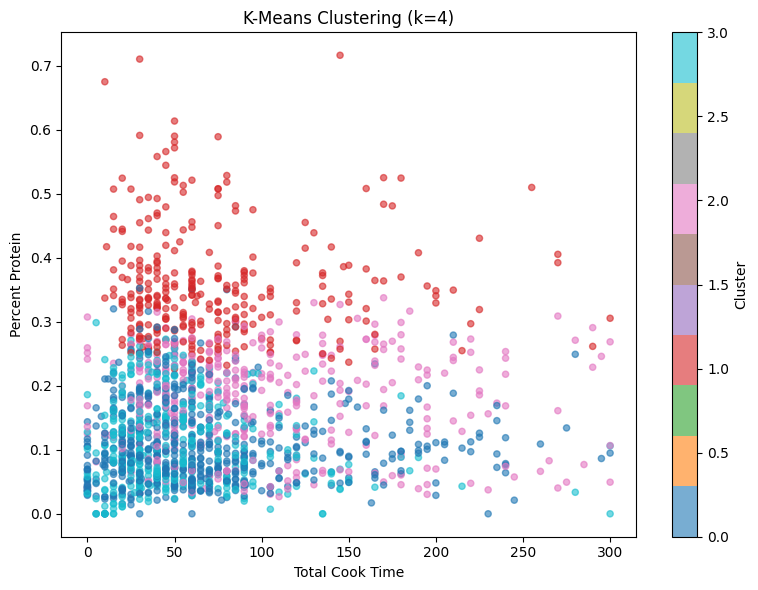

In [109]:
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, random_state=272)
km_labels = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(pd.Series(km_labels).value_counts().sort_index().rename('n'))
print(f"Converged in {kmeans.n_iter_} iterations")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(cuisines_clean['total_time'],
                      cuisines_clean['pct_protein'],
                      c=km_labels, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Total Cook Time')
plt.ylabel('Percent Protein')
plt.title('K-Means Clustering (k=4)')
plt.tight_layout()
plt.show()

We see some grouping, definitely a red cluster and possibly pink separated, but teal and blue are not well separated.

How should we choose k?

## Choosing $k$: The Elbow Method

A fundamental challenge in K-Means is selecting $k$. Inertia (within cluster sum of squares) **always decreases** as $k$ increases. At $k = n$ every point is its own cluster and inertia = 0. We look for an **"elbow"** where the rate of improvement sharply drops off.

This is a heuristic, not a formal test!

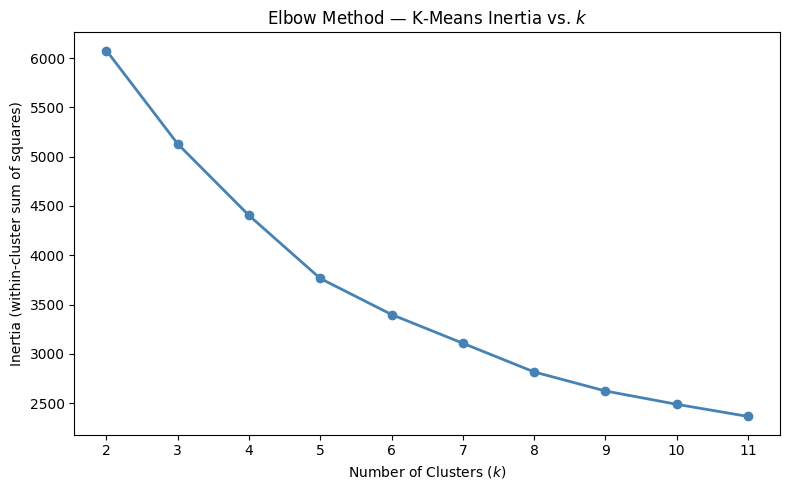

In [110]:
k_range = range(2, 12)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=272)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method — K-Means Inertia vs. $k$')
plt.xticks(list(k_range))
plt.tight_layout()
plt.show()

It looks like k=5 is a good "elbow" in our cuisines application.

## Choosing $k$: Silhouette Score

Another way to select $k$ is through the **silhouette score**, which measures how well each observation fits its own cluster compared to the next-nearest cluster.

For observation $i$:
- $a(i)$ = mean distance to all other points **in the same cluster** (cohesion)
- $b(i)$ = mean distance to all points **in the nearest other cluster** (separation)

$$s(i) = \frac{b(i) - a(i)}{\max(a(i),\, b(i))} \quad \in [-1, 1]$$

- $s(i) \approx 1$: well-assigned
- $s(i) \approx 0$: on the boundary between clusters
- $s(i) < 0$: likely misassigned

The **average silhouette score** across all observations is a summary: **higher is better**.

Best k by silhouette score: 2  (score = 0.2521)


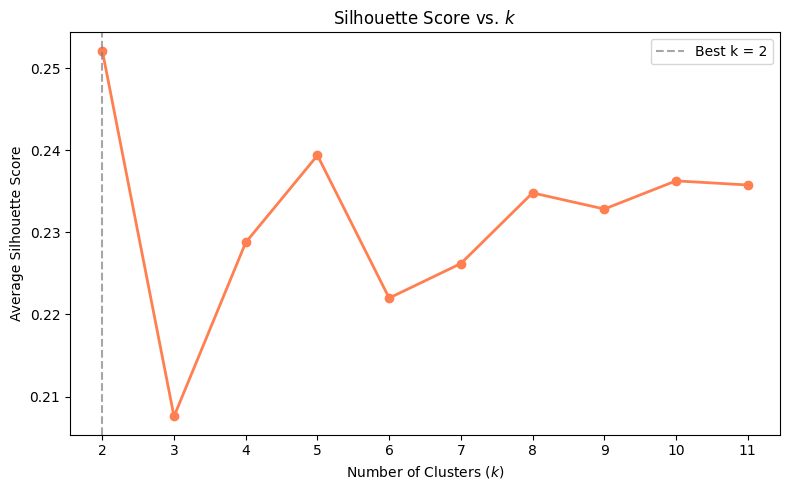

In [111]:
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=272)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels, sample_size=500, random_state=272)
    silhouette_scores.append(score)

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Best k by silhouette score: {best_k}  (score = {max(silhouette_scores):.4f})")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, 'o-', color='coral', linewidth=2)
plt.axvline(x=best_k, linestyle='--', color='gray', alpha=0.7, label=f'Best k = {best_k}')
plt.xlabel('Number of Clusters ($k$)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Score vs. $k$')
plt.xticks(list(k_range))
plt.legend()
plt.tight_layout()
plt.show()

Let's look at another type of clustering before discussing how to interpret clusters.

# Hierarchical Clustering

**Hierarchical (agglomerative) clustering** takes a different approach to K-Means. Rather than jumping straight to $k$ groups, it builds a full **tree of merges** from the bottom up:

1. **Start** — every observation is its own cluster ($n$ clusters total)
2. **Merge** — find the two closest clusters and combine them into one
3. **Repeat** — keep merging until everything is in a single cluster

**Where Euclidean distance comes in:**

At every merge step the algorithm needs to answer: *which two clusters are closest?* This is computed in two stages:

- **Between observations** — the raw distance between any two points $\mathbf{a}$ and $\mathbf{b}$ is Euclidean distance: $d(\mathbf{a}, \mathbf{b}) = \sqrt{\sum_{j=1}^{p}(a_j - b_j)^2}$
- **Between clusters** — once you have pairwise point distances, the **linkage criterion** defines how to summarize them into a single cluster-to-cluster distance (see table below)

So Euclidean distance is the foundation.

For the recipes data, distance is a measures how far apart individual recipes are in the feature space. Linkage then builds on top of that to decide which *groups* to merge. This is also why standardization matters: if `calories` has a range 10x larger than `pct_fat`, the Euclidean distance will be dominated by `calories` and the other features barely contribute.

The result is a **dendrogram** — a tree diagram where the height of each join shows how dissimilar the two clusters were when they merged. You choose how many clusters to keep by drawing a horizontal cut across the tree: the number of vertical lines the cut crosses is your $k$.

**Linkage** controls how the distance between two *clusters* is computed from pairwise point distances:

| Method | Distance between clusters $A$ and $B$ |
|---|---|
| **Single** | Nearest pair: $\min_{a \in A, b \in B} d(a,b)$ |
| **Complete** | Farthest pair: $\max_{a \in A, b \in B} d(a,b)$ |
| **Average** | Mean of all pairwise distances |
| **Ward** | Minimizes total within-cluster variance: $d(A,B) = \sqrt{\dfrac{2\,n_A n_B}{n_A + n_B}}\,\|\bar{\mathbf{x}}_A - \bar{\mathbf{x}}_B\|$ |

Ward linkage is usually preferred.

We use the simulated data first so the dendrogram structure is easy to read.

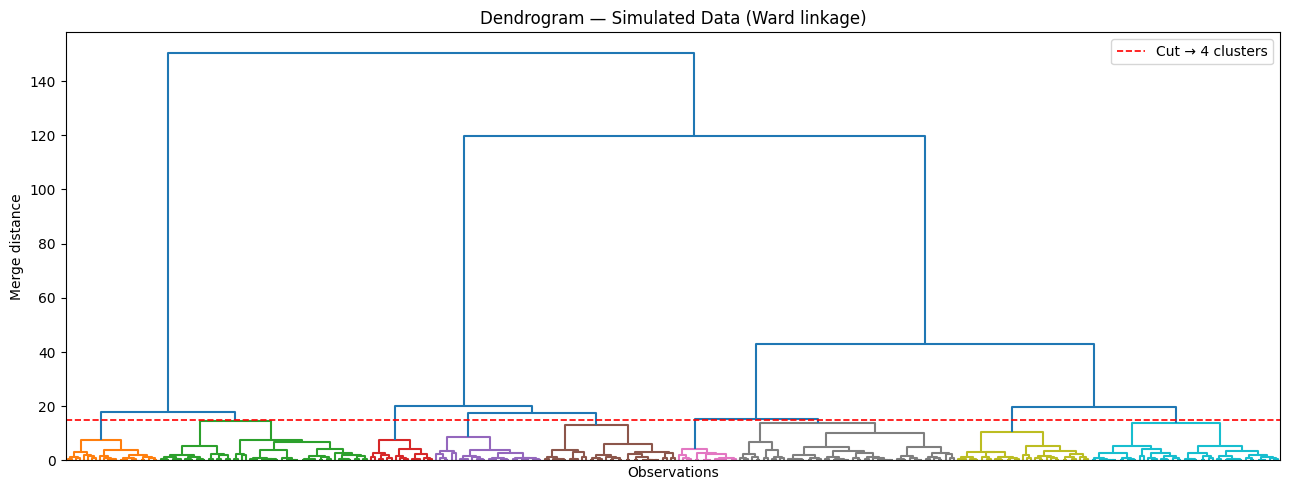

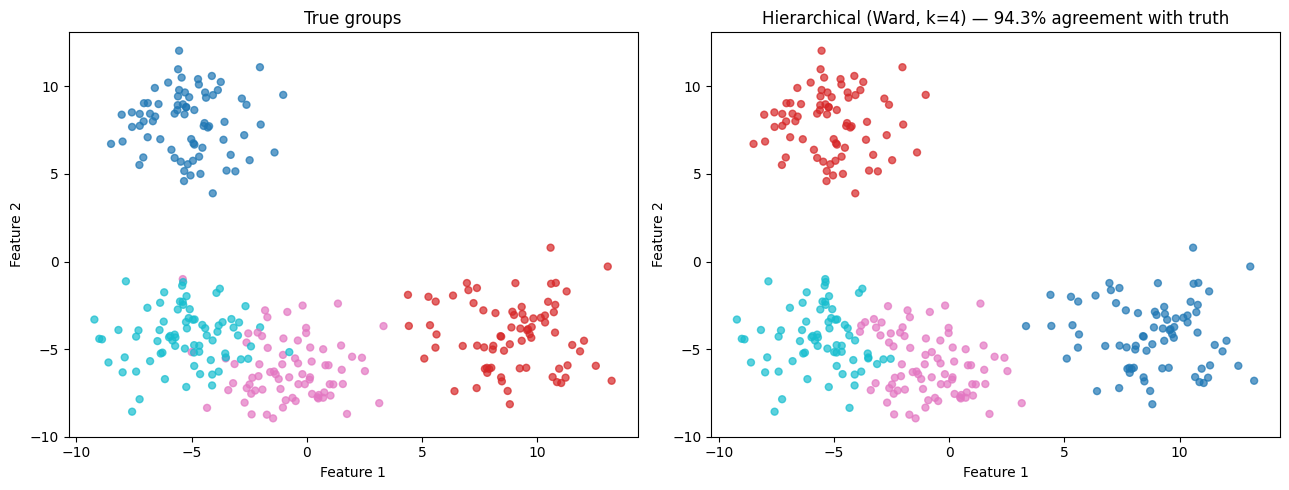

In [112]:
linkage_matrix = sch.linkage(X_sim, method='ward')

plt.figure(figsize=(13, 5))
sch.dendrogram(linkage_matrix, no_labels=True, color_threshold=15)
plt.axhline(y=15, color='red', linestyle='--', linewidth=1.2, label='Cut → 4 clusters')
plt.title('Dendrogram — Simulated Data (Ward linkage)')
plt.xlabel('Observations')
plt.ylabel('Merge distance')
plt.legend()
plt.tight_layout()
plt.show()

# Fit agglomerative clustering and compare to truth
agg_sim = AgglomerativeClustering(n_clusters=4, linkage='ward')
agg_labels_sim = agg_sim.fit_predict(X_sim)

# Align labels for comparison
from scipy.stats import mode
label_map = {}
for k in range(4):
    mask = agg_labels_sim == k
    label_map[k] = mode(y_sim[mask], keepdims=True).mode[0]
agg_aligned = np.array([label_map[l] for l in agg_labels_sim])
agg_accuracy = (agg_aligned == y_sim).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_sim[:, 0], X_sim[:, 1], c=y_sim, cmap='tab10', alpha=0.7, s=25)
axes[0].set_title('True groups')
axes[1].scatter(X_sim[:, 0], X_sim[:, 1], c=agg_labels_sim, cmap='tab10', alpha=0.7, s=25)
axes[1].set_title(f'Hierarchical (Ward, k=4) — {agg_accuracy:.1%} agreement with truth')
for ax in axes:
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

### Reading the Dendrogram

- Each **leaf** at the bottom represents one observation.
- Each **horizontal line** is a merge; its **height** is the distance at which the merge occurred.
- A **horizontal cut** at height $h$ yields the number of clusters equal to the number of vertical lines the cut crosses.
- Long vertical lines just before a merge indicate a **natural gap** — a good place to cut.


Let's try hierarchical clustering on the cuisine/recipe data.

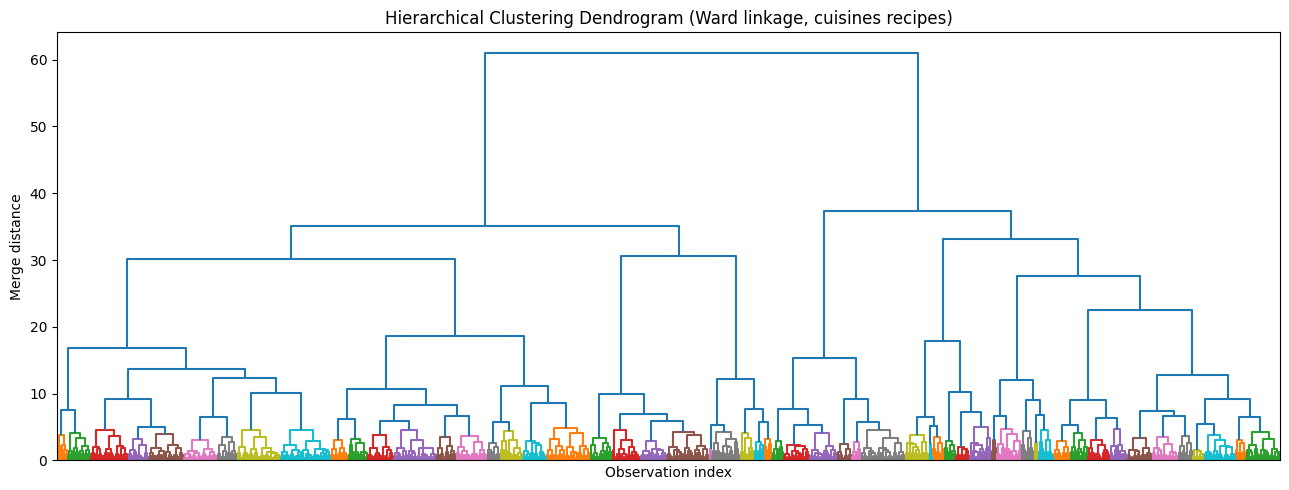

In [113]:
# Note if your data are large, might want to use a smaller subset for the dendrogram (hierarchical clustering is O(n^2))

linkage_matrix = sch.linkage(X_scaled, method='ward')

plt.figure(figsize=(13, 5))
sch.dendrogram(linkage_matrix, no_labels=True, color_threshold=5)
plt.title('Hierarchical Clustering Dendrogram (Ward linkage, cuisines recipes)')
plt.xlabel('Observation index')
plt.ylabel('Merge distance')
plt.tight_layout()
plt.show()

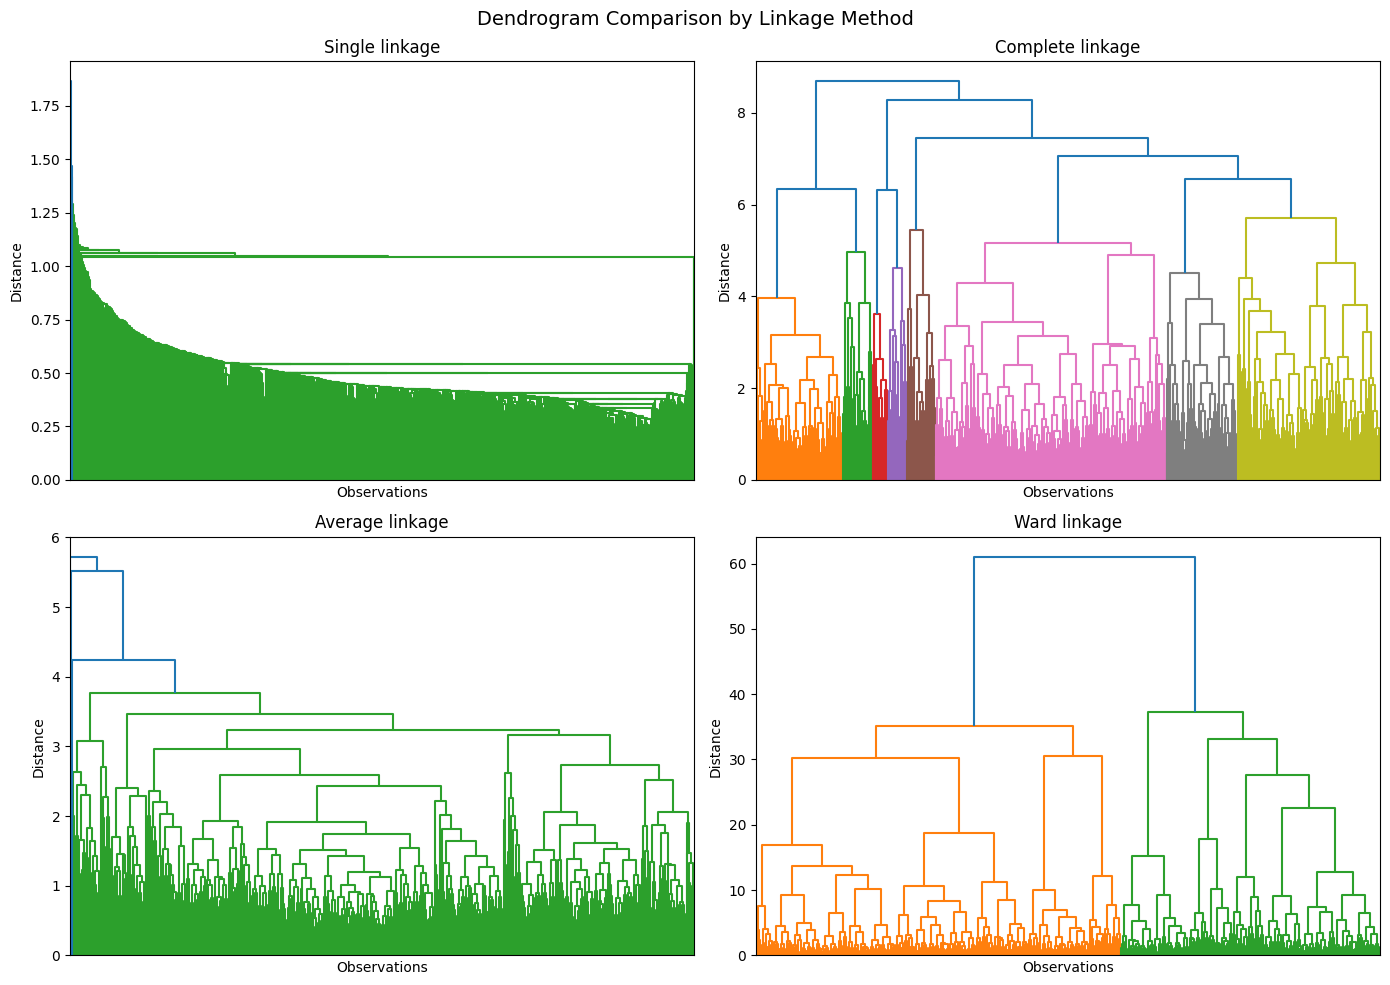

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
methods = ['single', 'complete', 'average', 'ward']

for ax, method in zip(axes.flatten(), methods):
    lm = sch.linkage(X_scaled, method=method)
    sch.dendrogram(lm, no_labels=True, ax=ax)
    ax.set_title(f'{method.capitalize()} linkage', fontsize=12)
    ax.set_xlabel('Observations')
    ax.set_ylabel('Distance')

plt.suptitle('Dendrogram Comparison by Linkage Method', fontsize=14)
plt.tight_layout()
plt.show()

### Interpreting the Dendrograms

**How colors are assigned:** Each subtree that merges *below* the color threshold gets its own color; anything that merges *above* the threshold is drawn in the default blue/grey. The threshold is set automatically to $0.7 \times$ the maximum merge height in that plot, which is why the coloring looks different across the four linkage panels — each method has a different height scale. The colors themselves (blue, orange, green, …) are just sequential labels with no intrinsic meaning.

**Choosing $k$ from the Ward dendrogram:** Look for the **largest vertical gaps**. A long vertical line means the two clusters being joined were quite dissimilar, so the merge is costly. A horizontal cut drawn just below such a gap captures natural groupings in the data.

In the cuisines Ward dendrogram, the tree shows a large gap at roughly distance 20-25 on y-axis, suggesting 4-5 clusters is a natural break point. This is consistent with what the elbow and silhouette plots suggested for K-means.

**Why Ward looks cleanest:** Single linkage tends to produce long chains (one big cluster that slowly absorbs everything), complete and average can be sensitive to outliers, while Ward minimizes within-cluster variance at each merge — producing more compact, balanced clusters that are easier to interpret.

### Fitting Hierarchical (Agglomerative) Clustering

Once we decide on the number of clusters (from the dendrogram or domain knowledge), we fit `AgglomerativeClustering` on the full scaled dataset.

Cluster sizes:
0    251
1    736
2    184
3    398
4    119
Name: n, dtype: int64


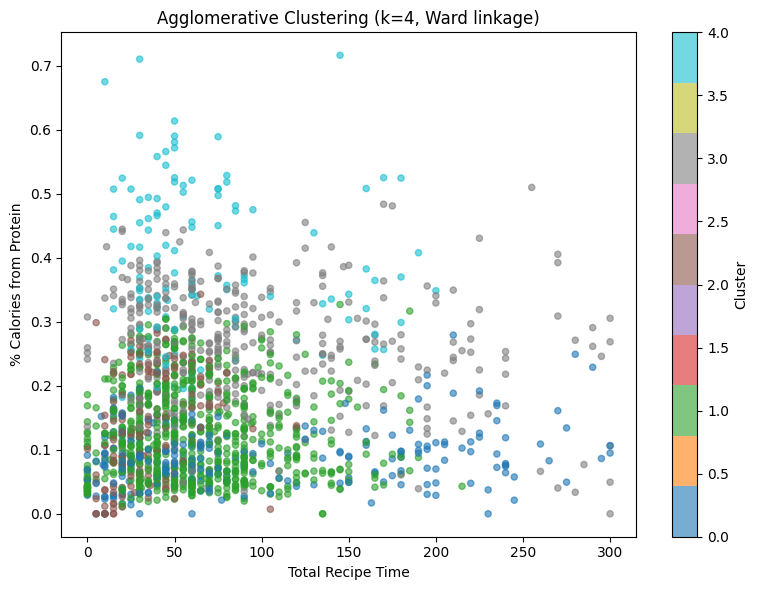

In [115]:
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

print("Cluster sizes:")
print(pd.Series(agg_labels).value_counts().sort_index().rename('n'))

plt.figure(figsize=(8, 6))
scatter = plt.scatter(cuisines_clean['total_time'],
                      cuisines_clean['pct_protein'],
                      c=agg_labels, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Total Recipe Time')
plt.ylabel('% Calories from Protein')
plt.title('Agglomerative Clustering (k=4, Ward linkage)')
plt.tight_layout()
plt.show()

In [116]:
cuisines_agg = cuisines_clean.copy()
cuisines_agg['agg_cluster'] = agg_labels

profile_agg = (cuisines_agg
               .groupby('agg_cluster')[cuisine_features]
               .mean()
               .round(2))
profile_agg.index = [f'Cluster {i}' for i in profile_agg.index]
print("Agglomerative Cluster Profiles (feature means):")
print(profile_agg.to_string())

print()
print("Country breakdown by cluster (top 5 per cluster):")
for cid in sorted(cuisines_agg['agg_cluster'].unique()):
    subset = cuisines_agg[cuisines_agg['agg_cluster'] == cid]
    top = subset['country'].value_counts().head(5)
    print(f"\nCluster {cid}  (n={len(subset)}):")
    for country, count in top.items():
        print(f"  {country}: {count}  ({count/len(subset)*100:.1f}%)")

Agglomerative Cluster Profiles (feature means):
           calories  pct_fat  pct_carbs  pct_protein  total_time
Cluster 0    243.52     0.21       0.71         0.09       95.73
Cluster 1    334.24     0.43       0.47         0.12       63.49
Cluster 2    273.82     0.72       0.17         0.14       36.46
Cluster 3    490.57     0.54       0.20         0.26       95.27
Cluster 4    256.55     0.26       0.34         0.39       68.61

Country breakdown by cluster (top 5 per cluster):

Cluster 0  (n=251):
  Australian and New Zealander: 19  (7.6%)
  Jewish: 15  (6.0%)
  Canadian: 15  (6.0%)
  Brazilian: 13  (5.2%)
  Puerto Rican: 10  (4.0%)

Cluster 1  (n=736):
  Amish and Mennonite: 37  (5.0%)
  Australian and New Zealander: 30  (4.1%)
  Jewish: 28  (3.8%)
  Russian: 26  (3.5%)
  Chinese: 26  (3.5%)

Cluster 2  (n=184):
  Indian: 12  (6.5%)
  Thai: 12  (6.5%)
  Cajun and Creole: 10  (5.4%)
  Russian: 9  (4.9%)
  Soul Food: 9  (4.9%)

Cluster 3  (n=398):
  Cajun and Creole: 21  (5.3%)
 

## Evaluation Metrics for Clustering

Unlike supervised learning, there is no single "correct" answer for clustering. We use **internal** metrics that assess cluster quality based on the data itself (no labels needed).

| Metric | Formula (sketch) | Range | Better |
|---|---|---|---|
| **Inertia** | $\sum_j \sum_{x \in C_j} \|x - \mu_j\|^2$ | $[0, \infty)$ | Lower |
| **Silhouette** | mean of $s(i)$ across all $i$ | $[-1, 1]$ | Higher |
| **Davies-Bouldin** | avg. ratio of within-cluster scatter to between-cluster distance | $[0, \infty)$ | Lower |
| **Calinski-Harabasz** | ratio of between-cluster to within-cluster dispersion | $[0, \infty)$ | Higher |

No single metric tells the full story — use them in combination and **always interpret clusters substantively**.

In [117]:
km_best = KMeans(n_clusters=best_k, n_init=10, random_state=272)
km_best_labels = km_best.fit_predict(X_scaled)

results = [
    ('K-Means (k=4)',              km_labels),
    (f'K-Means (k={best_k})',      km_best_labels),
    ('Agglomerative (k=5, Ward)',  agg_labels),
]

rows = []
for name, labels in results:
    rows.append({
        'Method':               name,
        'Silhouette ↑':         round(silhouette_score(X_scaled, labels), 4),
        'Davies-Bouldin ↓':     round(davies_bouldin_score(X_scaled, labels), 4),
        'Calinski-Harabasz ↑':  round(calinski_harabasz_score(X_scaled, labels), 2),
    })

metrics_df = pd.DataFrame(rows).set_index('Method')
print(metrics_df.to_string())

                           Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
Method                                                                        
K-Means (k=4)                    0.2389            1.3616               514.45
K-Means (k=2)                    0.2602            1.4641               656.00
Agglomerative (k=5, Ward)        0.1506            1.5521               332.18


## Interpreting Clusters: Profiling

Metrics tell us about cluster **quality**, but not **meaning**. To understand what each cluster represents, we compute the mean of each feature within each cluster — and bring in the `country` variable (not used during clustering) to see whether the clusters align with real-world culinary traditions.

In [118]:
cuisines_clustered = cuisines_clean.copy()
cuisines_clustered['km_cluster'] = km_best_labels

profile_km = (cuisines_clustered
              .groupby('km_cluster')[cuisine_features]
              .mean()
              .round(2))
profile_km.index = [f'Cluster {i}' for i in profile_km.index]

print(f"K-Means Cluster Profiles (k={best_k}, feature means):")
print(profile_km.to_string())

print()
print("Country breakdown by cluster (top 5 per cluster):")
for cluster_id in sorted(cuisines_clustered['km_cluster'].unique()):
    subset = cuisines_clustered[cuisines_clustered['km_cluster'] == cluster_id]
    top_countries = subset['country'].value_counts().head(5)
    print(f"\nCluster {cluster_id} (n={len(subset)}):")
    for country, count in top_countries.items():
        print(f"  {country}: {count} ({count/len(subset)*100:.1f}%)")

K-Means Cluster Profiles (k=2, feature means):
           calories  pct_fat  pct_carbs  pct_protein  total_time
Cluster 0    413.83     0.55       0.23         0.23       76.87
Cluster 1    271.52     0.33       0.58         0.11       69.20

Country breakdown by cluster (top 5 per cluster):

Cluster 0 (n=878):
  Chinese: 40 (4.6%)
  Cajun and Creole: 39 (4.4%)
  Tex-Mex: 38 (4.3%)
  French: 36 (4.1%)
  Thai: 35 (4.0%)

Cluster 1 (n=810):
  Australian and New Zealander: 47 (5.8%)
  Amish and Mennonite: 39 (4.8%)
  Jewish: 35 (4.3%)
  Canadian: 34 (4.2%)
  Brazilian: 34 (4.2%)


## Comparing Clustering Algorithms

| Algorithm | Key strength | Key limitation | When to use |
|---|---|---|---|
| **K-Means** | Fast, scalable, easy to interpret | Assumes spherical clusters; needs $k$ | Large datasets, roughly globular clusters |
| **Agglomerative** | No $k$ needed upfront; dendrogram aids interpretation | Can be computationally intensive; merges are irreversible | Small–medium datasets; need hierarchical structure |


### Summary

- Clustering is an **exploratory** tool — there is no single correct answer.
- Always **standardize** your features before distance-based clustering.
- Use the **elbow method** and **silhouette score** together to guide the choice of $k$.
- Use **multiple metrics** and — most importantly — **substantive interpretation** to evaluate clusters.
- The clusters discovered are a starting point for analysis, not a definitive truth. Validate with domain knowledge and outcomes not used in clustering.